In [1]:
import sys, os
import pandas, numpy, scipy
import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import seaborn

pathways = {}
pathways["CURRENT_PATH"] = os.getcwd()
pathways["MRIO_PATH"] = os.path.join(pathways["CURRENT_PATH"], 'data', 'FIGARO')
pathways["GENERAL_DATA_PATH"] = os.path.join(pathways["CURRENT_PATH"], 'data', 'GENERAL_DATA')
pathways["MODULE_PATH"] = os.path.join(pathways["CURRENT_PATH"], 'modules')

sys.path.insert(0, pathways["MODULE_PATH"])

from transition_models import *
from leontief_model import *
from utils import *
from data_load import *
# from financial_models import *

In [2]:
sector_name = 'NACE1'
exclude_sectors = [] # "T", "U"
precision = None

##### Compute earnings shock with unit PTR

In [3]:
%%time

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=1.0, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

model_leontief = carbon_var_ptr.model_VaR["leontief"]

CPU times: total: 12.7 s
Wall time: 9.57 s


In [4]:
%%time

df_ghg = model_leontief.dict_financials_gs['ghg']
df_output = model_leontief.dict_financials_gs['output']
df_gva = model_leontief.dict_financials_gs['gva']

df_G = (df_ghg / df_output).fillna(0.0)
df_v = (df_gva / df_output).fillna(0.0)

df_delta_p_costpush, df_delta_p_tax, df_delta_p_ic = {}, {}, {}

for carbon_price in [25, 50, 100, 250]:
    delta_c = df_G * carbon_price
    delta_p_costpush = model_leontief.inflation_from_va(delta_c)
    delta_p_tax = model_leontief.inflation_from_inflation(delta_c)
    delta_p_intermediary = model_leontief.inflation_from_intermediary(delta_c)
    
    df_delta_p_costpush[carbon_price] = delta_p_costpush * 100
    df_delta_p_tax[carbon_price] = delta_p_tax * 100
    df_delta_p_ic[carbon_price] = delta_p_intermediary * 100
    
df_delta_p_costpush = pandas.DataFrame(df_delta_p_costpush).round(5)
df_delta_p_tax = pandas.DataFrame(df_delta_p_tax).round(5)
df_delta_p_ic = pandas.DataFrame(df_delta_p_ic).round(5)

df_mean_inflation = pandas.DataFrame(
    [
    df_delta_p_costpush.T.dot(df_output / df_output.sum()),
    df_delta_p_tax.T.dot(df_output / df_output.sum()),
    df_delta_p_ic.T.dot(df_output / df_output.sum()),
    ], index=["P", "M", "IC"]
)

df_mean_inflation

CPU times: total: 47.9 s
Wall time: 17 s


,25,50,100,250
P,0.740501,1.481002,2.962003,7.405009
M,1.745886,3.598948,7.691330,25.897331
IC,1.102202,2.274995,4.875880,16.650906


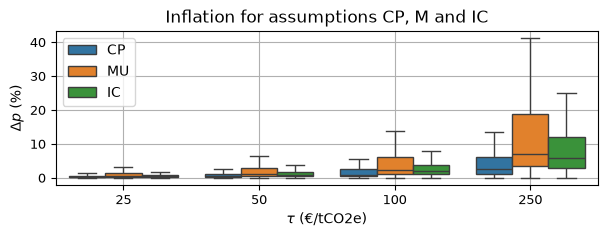

In [5]:
df_1 = df_delta_p_costpush.copy()
df_1["Source"] = "CP"
df_2 = df_delta_p_tax.copy()
df_2["Source"] = "MU"
df_3 = df_delta_p_ic.copy()
df_3["Source"] = "IC"

df_boxplot = pandas.concat([df_1, df_2, df_3])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\tau$ (€/tCO2e)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title(r"Inflation for assumptions CP, M and IC")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "deltap_carbon.png"), dpi=300, bbox_inches='tight')

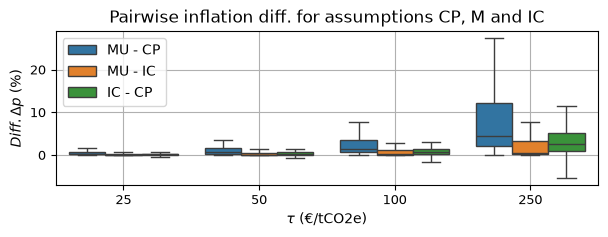

In [6]:
df_1 = (df_delta_p_tax - df_delta_p_costpush).copy()
df_1["Source"] = "MU - CP"
df_2 = (df_delta_p_tax - df_delta_p_ic).copy()
df_2["Source"] = "MU - IC"
df_3 = (df_delta_p_ic - df_delta_p_costpush).copy()
df_3["Source"] = "IC - CP"

df_boxplot = pandas.concat([df_1, df_2, df_3])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\tau$ (€/tCO2e)")
plt.ylabel(r"$Diff. \Delta p$ (%)")
plt.title(r"Pairwise inflation diff. for assumptions CP, M and IC")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "deltap_carbon_comparisons.png"), dpi=300, bbox_inches='tight')

In [7]:
carbon_price = 100

delta_p = df_G * carbon_price

delta_p_costpush = model_leontief.inflation_from_va(delta_p)
delta_p_tax = model_leontief.inflation_from_inflation(delta_p)
delta_p_intermediary = model_leontief.inflation_from_intermediary(delta_p)

d = pandas.DataFrame(numpy.diag(1 + delta_p), 
                    index=model_leontief.A.index, 
                    columns=model_leontief.A.columns)
D = numpy.linalg.pinv(d)
A = model_leontief.A
I = numpy.eye(*A.shape)

model_leontief.L_mu = model_leontief.L_mu.round(8)
model_leontief.L_cp = model_leontief.L_cp.round(8)
model_leontief.L_ic = model_leontief.L_ic.round(8)

print("{:.2%}".format((model_leontief.L_mu >= model_leontief.L_cp).mean().mean()), 
      "{:.2%}".format((model_leontief.L_mu >= model_leontief.L_ic).mean().mean()), 
      "{:.2%}".format((model_leontief.L_ic >= model_leontief.L_cp).mean().mean()))
print("{:.2%}".format(((model_leontief.L_ic - I) >= (model_leontief.L_cp - d.values)).mean().mean()))

100.00% 100.00% 99.91%
100.00%


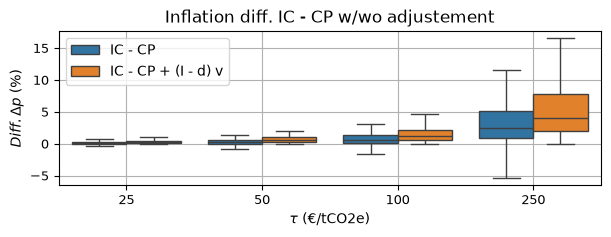

In [8]:
df_1 = (df_delta_p_tax - df_delta_p_costpush).copy()
df_1["Source"] = "MU - CP"
df_2 = (df_delta_p_tax - df_delta_p_ic).copy()
df_2["Source"] = "MU - IC"
df_3 = (df_delta_p_ic - df_delta_p_costpush).copy()
df_3["Source"] = "IC - CP"

df_4 = (df_delta_p_ic - df_delta_p_costpush).copy()

for carbon_price in df_4.columns:
    d = pandas.DataFrame(numpy.diag(1 + df_G * carbon_price), 
                            index=model_leontief.A.index, 
                            columns=model_leontief.A.columns)
    df_4[carbon_price] = df_4[carbon_price] - (df_v - d.dot(df_v)) * 100

df_4["Source"] = "IC - CP + (I - d) v"

df_boxplot = pandas.concat([df_3, df_4])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\tau$ (€/tCO2e)")
plt.ylabel(r"$Diff. \Delta p$ (%)")
plt.title(r"Inflation diff. IC - CP w/wo adjustement")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "diff_deltap_P_vs_IC_adjusted.png"), dpi=300, bbox_inches='tight')

In [9]:
%%time

df_ghg = model_leontief.dict_financials_gs['ghg']
df_output = model_leontief.dict_financials_gs['output']
df_gva = model_leontief.dict_financials_gs['gva']

df_G = (df_ghg / df_output).fillna(0.0)
df_v = (df_gva / df_output).fillna(0.0)

df_delta_p_costpush_dp, df_delta_p_costpush_dv = {}, {}

for carbon_price in [25, 50, 100, 250]:
    delta_p = df_G * carbon_price
    delta_v = (delta_p / df_v).fillna(0.0) * (df_v > 0)
    
    delta_p_costpush_dp = model_leontief.inflation_from_va(delta_p)
    delta_p_costpush_dv = model_leontief.inflation_from_va(delta_v)
    
    df_delta_p_costpush_dp[carbon_price] = delta_p_costpush_dp * 100
    df_delta_p_costpush_dv[carbon_price] = delta_p_costpush_dv * 100

df_delta_p_costpush_dp = pandas.DataFrame(df_delta_p_costpush_dp)
df_delta_p_costpush_dv = pandas.DataFrame(df_delta_p_costpush_dv)

df_mean_inflation = pandas.DataFrame([
    df_delta_p_costpush_dp.T.dot(df_output / df_output.sum()), 
    df_delta_p_costpush_dv.T.dot(df_output / df_output.sum()), 
    ], index=["P_dp", "P_dv"])

df_mean_inflation

CPU times: total: 1.38 s
Wall time: 584 ms


,25,50,100,250
P_dp,0.740501,1.481002,2.962003,7.405009
P_dv,1.696620,3.393239,6.786479,16.966197


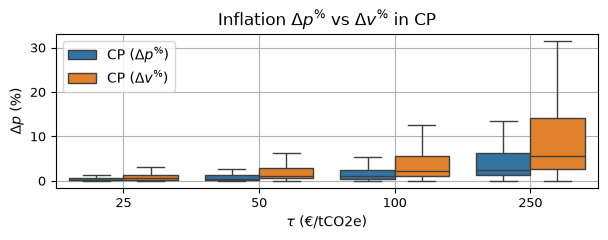

In [10]:
df_1 = df_delta_p_costpush_dp.copy()
df_1["Source"] = r"CP ($\Delta p^{\%}$)"
df_2 = df_delta_p_costpush_dv.copy()
df_2["Source"] = r"CP ($\Delta v^{\%})$"

df_boxplot = pandas.concat([df_1, df_2])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\tau$ (€/tCO2e)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title(r"Inflation $\Delta p^{\%}$ vs $\Delta v^{\%}$ in CP")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "cp_dp_dv.png"), dpi=300, bbox_inches='tight')

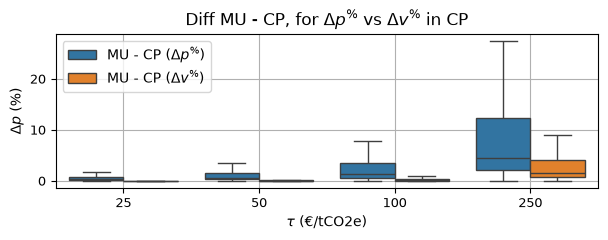

In [11]:
df_1 = (df_delta_p_tax - df_delta_p_costpush_dp).copy()
df_1["Source"] = r"MU - CP (${\Delta} p^{\%}$)"
df_2 = (df_delta_p_tax - df_delta_p_costpush_dv).copy()
df_2["Source"] = r"MU - CP (${\Delta} v^{\%}$)"

df_boxplot = pandas.concat([df_1, df_2])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\tau$ (€/tCO2e)")
plt.ylabel(r"${\Delta} p$ (%)")
plt.title(r"Diff MU - CP, for ${\Delta} p^{\%}$ vs ${\Delta} v^{\%}$ in CP")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "mu_cp_dp_dv.png"), dpi=300, bbox_inches='tight')

In [12]:
carbon_price = 100

delta_p = df_G * carbon_price
delta_v = (delta_p / df_v).fillna(0.0) * (df_v > 0)

D_v = pandas.DataFrame(numpy.diag(1 / (1 + delta_v)), 
                            index=model_leontief.A.index, 
                            columns=model_leontief.A.columns)

D_p = pandas.DataFrame(numpy.diag(1 / (1 + delta_p)), 
                            index=model_leontief.A.index, 
                            columns=model_leontief.A.columns)

I = pandas.DataFrame(numpy.eye(*model_leontief.A.shape), 
                            index=model_leontief.A.index, 
                            columns=model_leontief.A.columns)

delta_p_costpush_dp = model_leontief.inflation_from_inflation(delta_p)
delta_p_costpush_dv = model_leontief.inflation_from_va(delta_v)

X = (D_v - D_v.dot(model_leontief.A.T))
Y = (D_p - model_leontief.A.T)

df_z = numpy.linalg.pinv(X).dot(df_v)
network_effect = (I - D_v).dot(model_leontief.A.T).dot(df_z)
diagonal_effect = (D_p - D_v).dot(df_z)

print("Network effect higher than diagonal effect: {:.0%}".format((network_effect >= diagonal_effect).mean()))

Network effect higher than diagonal effect: 100%


##### Inflation with $\Phi=1$ versus $\Phi<1$

In [13]:
carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=1.0, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

init_ptr = carbon_var_ptr.model_VaR['leontief'].pass_through.copy()

model_leontief = carbon_var_ptr.model_VaR["leontief"]

df_ghg = model_leontief.dict_financials_gs['ghg']
df_output = model_leontief.dict_financials_gs['output']
df_gva = model_leontief.dict_financials_gs['gva']

df_G = (df_ghg / df_output).fillna(0.0)
df_v = (df_gva / df_output).fillna(0.0)

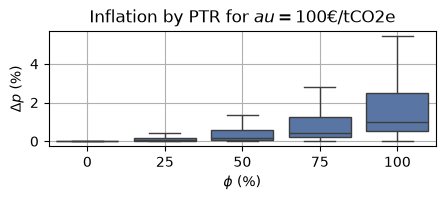

CPU times: total: 59 s
Wall time: 22 s


In [14]:
%%time

final_inflation_cp = {}

carbon_price = 100

for i in numpy.linspace(0, 1, 5):
    ptr = init_ptr * i
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    model_leontief = carbon_var_ptr.model_VaR["leontief"]
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)
    final_inflation_cp[int(i * 100)] = delta_p * 100

final_inflation_cp = pandas.concat(final_inflation_cp, axis=1)

plt.figure(figsize=(5, 1.5))
seaborn.boxplot(final_inflation_cp, showfliers=False, color="#4c72b0")
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title("Inflation by PTR for $\tau=$100€/tCO2e")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "inflation_by_ptr - CP.png"), dpi=300, bbox_inches='tight')

plt.show()

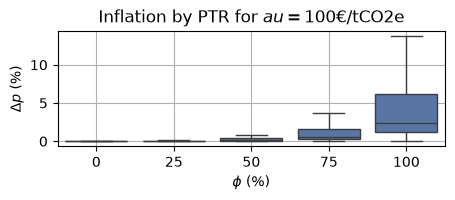

CPU times: total: 1min 27s
Wall time: 31.8 s


In [15]:
%%time

final_inflation_mu = {}

carbon_price = 100

for i in numpy.linspace(0, 1, 5):
    ptr = init_ptr * i
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    model_leontief = carbon_var_ptr.model_VaR["leontief"]
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_inflation(df_G * carbon_price)
    final_inflation_mu[int(i * 100)] = delta_p * 100

final_inflation_mu = pandas.concat(final_inflation_mu, axis=1)

plt.figure(figsize=(5, 1.5))
seaborn.boxplot(final_inflation_mu, showfliers=False, color="#4c72b0")
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title("Inflation by PTR for $\tau=$100€/tCO2e")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "inflation_by_ptr - MU.png"), dpi=300, bbox_inches='tight')

plt.show()

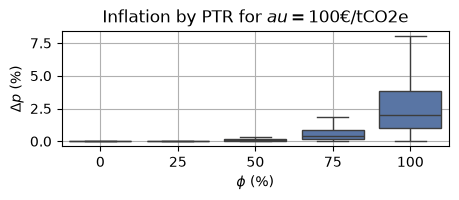

CPU times: total: 1min 29s
Wall time: 32.9 s


In [16]:
%%time

final_inflation_ic = {}

carbon_price = 100

for i in numpy.linspace(0, 1, 5):
    ptr = init_ptr * i
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    model_leontief = carbon_var_ptr.model_VaR["leontief"]
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_intermediary(df_G * carbon_price)
    final_inflation_ic[int(i * 100)] = delta_p * 100

final_inflation_ic = pandas.concat(final_inflation_ic, axis=1)

plt.figure(figsize=(5, 1.5))
seaborn.boxplot(final_inflation_ic, showfliers=False, color="#4c72b0")
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title("Inflation by PTR for $\tau=$100€/tCO2e")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "inflation_by_ptr - IC.png"), dpi=300, bbox_inches='tight')

plt.show()

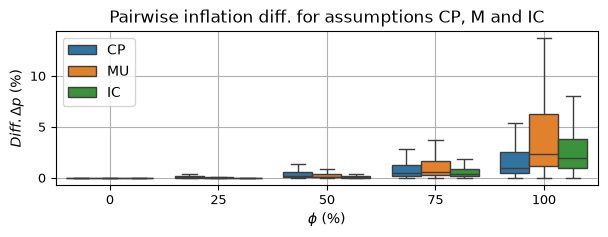

In [17]:
df_1 = (final_inflation_cp).copy()
df_1["Source"] = "CP"
df_2 = (final_inflation_mu).copy()
df_2["Source"] = "MU"
df_3 = (final_inflation_ic).copy()
df_3["Source"] = "IC"

df_boxplot = pandas.concat([df_1, df_2, df_3])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$Diff. \Delta p$ (%)")
plt.title(r"Pairwise inflation diff. for assumptions CP, M and IC")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "deltap_by_ptr_comparisons.png"), dpi=300, bbox_inches='tight')

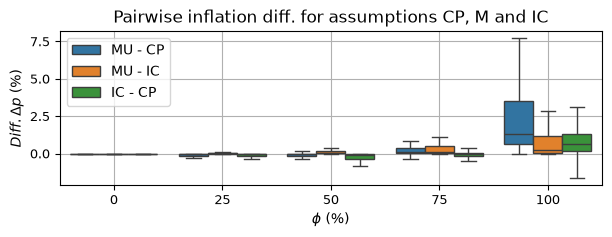

In [18]:
df_1 = (final_inflation_mu - final_inflation_cp).copy()
df_1["Source"] = "MU - CP"
df_2 = (final_inflation_mu - final_inflation_ic).copy()
df_2["Source"] = "MU - IC"
df_3 = (final_inflation_ic - final_inflation_cp).copy()
df_3["Source"] = "IC - CP"

df_boxplot = pandas.concat([df_1, df_2, df_3])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$Diff. \Delta p$ (%)")
plt.title(r"Pairwise inflation diff. for assumptions CP, M and IC")

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "deltap_by_ptr_pairwise_diff.png"), dpi=300, bbox_inches='tight')

##### Introduce PTR by sector

In [19]:
%%time

carbon_price = 100

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=0.5, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

delta_p_costpush = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)
init_ptr = carbon_var_ptr.model_VaR["leontief"].pass_through.copy()
sectors = carbon_var_ptr.model_VaR["leontief"].A.index.get_level_values(1).unique()

diff_inflation = {}

sector = "D"
ptr = init_ptr.copy()
ptr.loc[(slice(None), sector)] = 1.0
carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)

diff_inflation[sector] = 100 * (delta_p.drop(sector, level=1) - delta_p_costpush.drop(sector, level=1))

CPU times: total: 23 s
Wall time: 9.65 s


100%|██████████| 21/21 [01:36<00:00,  4.60s/it]


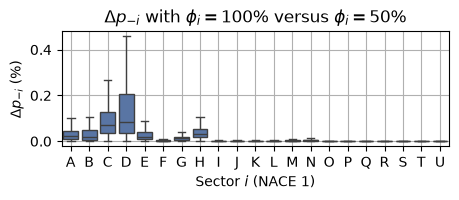

CPU times: total: 4min 20s
Wall time: 1min 41s


In [20]:
%%time

carbon_price = 100

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=0.5, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

delta_p_costpush = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)
init_ptr = carbon_var_ptr.model_VaR["leontief"].pass_through.copy()
sectors = carbon_var_ptr.model_VaR["leontief"].A.index.get_level_values(1).unique()

diff_inflation = {}

for sector in tqdm.tqdm(sectors):
    ptr = init_ptr.copy()
    ptr.loc[(slice(None), sector)] = 1.0
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)
    
    diff_inflation[sector] = 100 * (delta_p.drop(sector, level=1) - delta_p_costpush.drop(sector, level=1))
    
plt.figure(figsize=(5, 1.5))
seaborn.boxplot(pandas.concat(diff_inflation, axis=1), showfliers=False, color="#4c72b0")
plt.title(r"${\Delta} p_{-i}$ with $\phi_i=100\%$ versus $\phi_i=50\%$")
plt.xlabel(r"Sector $i$ (NACE 1)")
plt.ylabel(r"${\Delta} p_{-i}$ (%)")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "diff_p_ptr_sector.png"), dpi=300, bbox_inches='tight')

plt.show()

##### Exogenous sectors

100%|██████████| 21/21 [01:28<00:00,  4.23s/it]


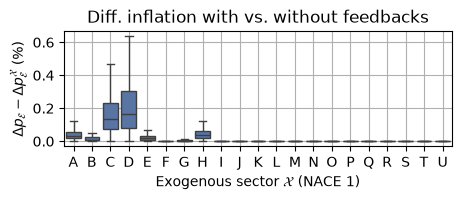

CPU times: total: 4min 3s
Wall time: 1min 34s


In [21]:
%%time

carbon_price = 100

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=1.0, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

model_leontief = carbon_var_ptr.model_VaR["leontief"]

sectors = model_leontief.A.index.get_level_values(1).unique()

df_results = {}
df_inflation_exogenous = {}

for sector in tqdm.tqdm(sectors):
    index_ = model_leontief.A.index.get_level_values(1).isin([sector])
    columns_ = model_leontief.A.columns.get_level_values(1).isin([sector])
    
    A_xe = model_leontief.A.loc[index_, ~columns_]
    A_ee = model_leontief.A.loc[~index_, ~columns_]

    dp = df_G * carbon_price
    dp[~index_] = 0.0
    
    B_ee = model_leontief.leontief_inverse_numerical(A_ee, None)
    delta_pe = B_ee.T.dot(A_xe.T.dot(dp[index_]))
    delta_pe = numpy.maximum(delta_pe, 0.0)
    
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_inflation(dp)
    delta_p = numpy.maximum(delta_p, 0.0)
    
    df_results[sector] = 100 * (delta_p[delta_pe.index] - delta_pe)
    df_inflation_exogenous[sector] = 100 * delta_pe

plt.figure(figsize=(5, 1.5))
seaborn.boxplot(pandas.concat(df_results, axis=1), showfliers=False, color="#4c72b0")
plt.title(r"Diff. inflation with vs. without feedbacks")
plt.xlabel(r"Exogenous sector $\mathcal{X}$ (NACE 1)")
plt.ylabel(r"$\Delta p_\mathcal{E} - \Delta p_\mathcal{E}^\mathcal{X}$ (%)")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "prices_exogenous_sectors.png"), dpi=300, bbox_inches='tight')

plt.show()

In [22]:
%%time

# Comparaison PTR - feedbacks 

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=1.0, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)

delta_p_costpush = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(df_G * carbon_price)
init_ptr = carbon_var_ptr.model_VaR["leontief"].pass_through.copy()
sectors = carbon_var_ptr.model_VaR["leontief"].A.index.get_level_values(1).unique()

init_ptr.loc[init_ptr.index] = 1.0

diff_inflation = {}

for sector in tqdm.tqdm(sectors):
    ptr = init_ptr.copy()
    ptr.loc[(slice(None), sector)] = 0.0
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    dp = carbon_var_ptr.model_VaR["leontief"].A.T.dot(df_G * carbon_price * (1 - ptr))
    delta_p = carbon_var_ptr.model_VaR["leontief"].L_Phi.T.dot(dp)
    
    diff_inflation[sector] = 100 * delta_p.drop(sector, level=1)

print("Max bound for feedback vs. ptr: ")
print("{:.5f}".format((pandas.concat(diff_inflation, axis=1) - pandas.concat(df_inflation_exogenous, axis=1)).abs().max().max()))

100%|██████████| 21/21 [01:45<00:00,  5.04s/it]

Max bound for feedback vs. ptr: 
0.00000
CPU times: total: 4min 28s
Wall time: 1min 51s


<unknown>:29: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.


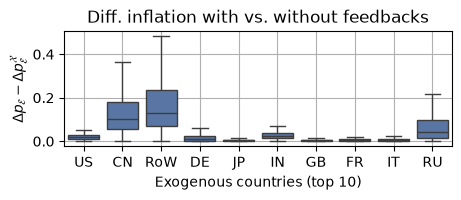

CPU times: total: 1min 56s
Wall time: 45.5 s


In [23]:
%%time

countries = model_leontief.dict_financials_gs["output"].groupby(level=0).sum().sort_values(ascending=False).index[:10]

df_results = {}

for country in countries:
    index_ = model_leontief.A.index.get_level_values(0).isin([country])
    columns_ = model_leontief.A.columns.get_level_values(0).isin([country])
    
    A_xe = model_leontief.A.loc[index_, ~columns_]
    A_ee = model_leontief.A.loc[~index_, ~columns_]
    
    dp = df_G * carbon_price
    dp[~index_] = 0.0
    
    B_ee = model_leontief.leontief_inverse_numerical(A_ee, None)
    delta_pe = B_ee.T.dot(A_xe.T.dot(dp[index_]))
    delta_pe = numpy.maximum(delta_pe, 0.0)
    
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_inflation(dp)
    delta_p = numpy.maximum(delta_p, 0.0)
    
    df_results[country] = 100 * (delta_p[delta_pe.index] - delta_pe)

plt.figure(figsize=(5, 1.5))
seaborn.boxplot(pandas.concat(df_results, axis=1).rename(columns={"FIGW1": "RoW"}), showfliers=False, color="#4c72b0")

plt.title(r"Diff. inflation with vs. without feedbacks")
plt.xlabel(f"Exogenous countries (top {len(countries)})")
plt.ylabel("$\Delta p_\mathcal{E}-\Delta p_\mathcal{E}^\mathcal{X}$")

plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "prices_exogenous_countries.png"), dpi=300, bbox_inches='tight')

plt.show()

##### Value added experiments

In [24]:
%%time

df_direct_results, df_indirect_results = {}, {}

carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
carbon_var_ptr.load_static_data(constant_ptr=1.0, year_mrio=None, exclude_sectors=exclude_sectors, precision=0)

init_ptr = carbon_var_ptr.model_VaR["leontief"].pass_through.copy()

for i in tqdm.tqdm(numpy.linspace(0, 1, 5)):
    ptr = init_ptr * i
    carbon_var_ptr = cost_earnings_VaR(pathways, sector_name)
    carbon_var_ptr.list_carbon_prices = [100]
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    
    final_direct_shock, final_indirect_shock, delta_p = carbon_var_ptr.compute_inflation_shocks()
    df_direct_results[int(i*100)] = 100 * final_direct_shock[carbon_var_ptr.start_date + 1]
    df_indirect_results[int(i*100)] = 100 * final_indirect_shock[carbon_var_ptr.start_date + 1]

100%|██████████| 5/5 [00:24<00:00,  4.92s/it]

CPU times: total: 1min 3s
Wall time: 25.1 s


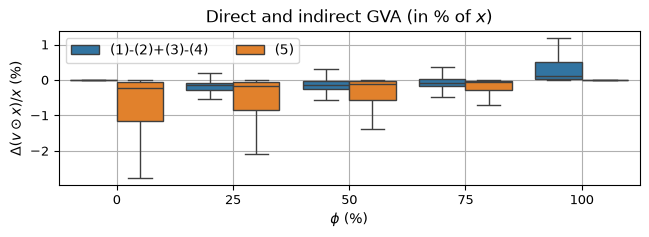

In [25]:
df_1 = pandas.concat(df_direct_results, axis=1).copy()
df_1["Source"] = "(5)"
df_2 = pandas.concat(df_indirect_results, axis=1).copy()
df_2["Source"] = "(1)-(2)+(3)-(4)"

df_boxplot = pandas.concat([df_2, df_1])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7.5, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta (v \odot x) / x$ (%)")
plt.title(r"Direct and indirect GVA (in % of $x$)")

plt.legend(ncol=2)

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "loss_gva_direct_indirect.png"), dpi=300, bbox_inches='tight')

##### Ghosh versus Leontief for x - application to MSA stress test

In [26]:
%%time

sector_name = 'NACE1'

A, L, dict_financials = load_leontief(pathways["MRIO_PATH"], 2022, sector_name)
B, G, dict_financials = load_ghosh(pathways["MRIO_PATH"], 2022, sector_name)

CPU times: total: 422 ms
Wall time: 454 ms


In [27]:
df_msa_st = pandas.read_excel(os.path.join(pathways["CURRENT_PATH"], "data", "MSA", "geosector_total_loss_MSA_SSP5RCP85_NACE1_FIGARO.xlsx"), index_col=[0, 1])
df_msa_st = df_msa_st[2030].fillna(0.0)
df_msa_st.index.names = [None, None]

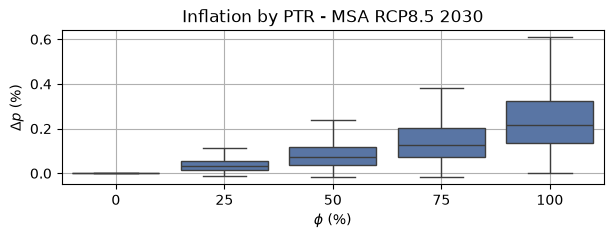

CPU times: total: 1min 2s
Wall time: 30.4 s


In [28]:
%%time

x = dict_financials["output"].fillna(0.0)
delta_x = x * df_msa_st
I = numpy.eye(B.shape[0])
delta_v = ((I - B.T).dot(delta_x) / x).fillna(0.0)

final_inflation = {}
df_direct_delta_v, df_indirect_delta_v = {}, {}

carbon_price = 100

for i in numpy.linspace(0, 1, 5):
    ptr = init_ptr * i
    carbon_var_ptr.load_static_data(constant_ptr=ptr, year_mrio=None, exclude_sectors=exclude_sectors, precision=precision)
    x = carbon_var_ptr.model_VaR["leontief"].dict_financials_gs["output"]
    
    delta_p = carbon_var_ptr.model_VaR["leontief"].inflation_from_va(-delta_v)
    dv_vc, delta_x, delta_y = carbon_var_ptr.model_VaR['leontief'].production_loss_from_inflation(delta_p)
    d_cost = delta_v * (1 - carbon_var_ptr.model_VaR['leontief'].pass_through) * (x * (1 + delta_x))
    d_cost = (d_cost / x).fillna(0.0)
    
    final_inflation[int(i * 100)] = delta_p * 100
    df_indirect_delta_v[int(i * 100)] = dv_vc * 100
    df_direct_delta_v[int(i * 100)] = d_cost * 100

plt.figure(figsize=(7, 2))
seaborn.boxplot(pandas.concat(final_inflation, axis=1), showfliers=False, color="#4c72b0")
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta p$ (%)")
plt.title("Inflation by PTR - MSA RCP8.5 2030")
plt.grid()

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "inflation_by_ptr_msa.png"), dpi=300, bbox_inches='tight')

plt.show()

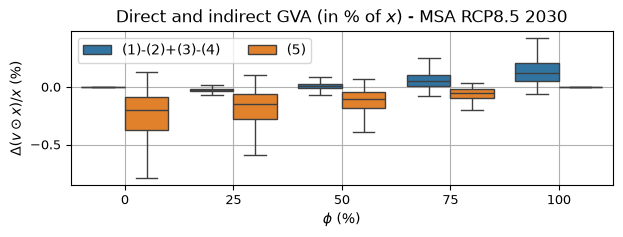

In [29]:
df_1 = pandas.concat(df_direct_delta_v, axis=1).copy()
df_1["Source"] = "(5)"
df_2 = pandas.concat(df_indirect_delta_v, axis=1).copy()
df_2["Source"] = "(1)-(2)+(3)-(4)"

df_boxplot = pandas.concat([df_2, df_1])
df_boxplot = pandas.melt(df_boxplot, id_vars=['Source'])

plt.figure(figsize=(7, 2))
seaborn.boxplot(df_boxplot, x='variable', y='value', hue='Source', showfliers=False)
plt.xticks(rotation=0, ha='center', fontsize=9);
plt.yticks(fontsize=9);
plt.legend(title=None);
plt.grid()
plt.xlabel(r"$\phi$ (%)")
plt.ylabel(r"$\Delta (v \odot x) / x$ (%)")
plt.title(r"Direct and indirect GVA (in % of $x$) - MSA RCP8.5 2030")

plt.legend(ncol=2)

plt.savefig(os.path.join(pathways["CURRENT_PATH"], "outputs", "loss_gva_direct_indirect_msa.png"), dpi=300, bbox_inches='tight')